# Disruption-prediction model: EDA + multi-model comparison

This notebook accompanies [src/training_pipeline.py](../src/training_pipeline.py)
and answers three questions:

1. **What does the data look like?** Disruption rates over time, by carrier,
   by destination, and conditioned on weather.
2. **How does the model perform?** Test-set metrics for the
   `HistGradientBoostingClassifier` trained by the pipeline.
3. **Is the choice of model the bottleneck?** Compare against a logistic-
   regression baseline and a LightGBM model on the same train/test split,
   with the same noise-injected weather features.

Calibration plots overlay all three models so we can see whether any of
them produce well-calibrated probabilities (spoiler: not really).


## 1. Setup

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Make `src.*` importable from a notebook.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.model.training_pipeline import (
    load_and_split, add_sampled_leads, prepare_features,
    build_test_occasions, inject_noise, per_occasion_table,
    TRAIN_START_DEFAULT, VAL_START_DEFAULT, TEST_START_DEFAULT,
)
from src.model.weather_noise import WeatherNoiseInjector

from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import lightgbm as lgb

JOINED   = ROOT / "data/processed/ord_flights_with_weather_2020_present.parquet"
SIGMAS   = ROOT / "data/processed/weather_noise_sigmas.json"
ARTIFACTS = ROOT / "artifacts/disruption_model"
SEED = 42

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.dpi"] = 110


## 2. EDA — what the data looks like

In [2]:
flights = pd.read_parquet(JOINED)
print(f"loaded {len(flights):,} rows from {JOINED.name}")
flights["scheduled_dep_utc_hour"] = pd.to_datetime(flights["scheduled_dep_utc_hour"], utc=True)
flights = flights.loc[flights["scheduled_dep_utc_hour"] >= TRAIN_START_DEFAULT].copy()
flights = flights.loc[flights["disrupted"].notna()].copy()
print(f"after dropping pre-2021 and missing labels: {len(flights):,} rows")
print(f"global base disruption rate: {flights['disrupted'].mean():.3f}")
flights[["flight_date", "reporting_airline", "dest", "disrupted",
         "origin_wx_tmpf", "origin_wx_gust", "origin_wx_vsby"]].head()


loaded 1,607,779 rows from ord_flights_with_weather_2020_present.parquet


after dropping pre-2021 and missing labels: 1,418,177 rows
global base disruption rate: 0.284


,flight_date,reporting_airline,dest,disrupted,origin_wx_tmpf,origin_wx_gust,origin_wx_vsby
189602,2020-12-31,OO,DSM,1,23.0000,NaN,8.0000
189603,2020-12-31,OO,OMA,0,23.0000,NaN,8.0000
189604,2020-12-31,OO,JST,0,23.0000,NaN,8.0000
189605,2020-12-31,OO,DEC,0,23.0000,NaN,8.0000
189606,2020-12-31,OO,JAX,0,23.0000,NaN,8.0000


### Disruption rate over time

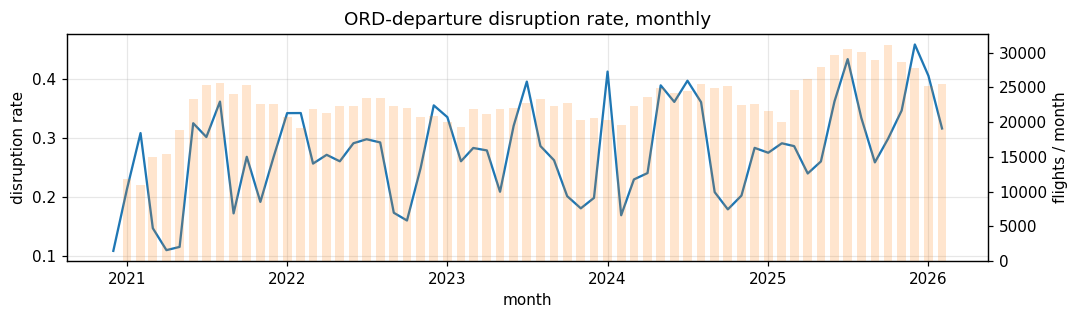

In [3]:
ym = (flights.assign(ym=flights["flight_date"].dt.to_period("M"))
              .groupby("ym")["disrupted"].agg(["mean", "size"])
              .reset_index())
ym["ym"] = ym["ym"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(10, 3))
ax1.plot(ym["ym"], ym["mean"], color="C0", lw=1.5, label="disruption rate")
ax1.set_ylabel("disruption rate")
ax1.set_xlabel("month")
ax1.set_title("ORD-departure disruption rate, monthly")
ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.bar(ym["ym"], ym["size"], color="C1", alpha=0.2, width=20, label="flights")
ax2.set_ylabel("flights / month")
fig.tight_layout()
plt.show()


**Note**: the trend up through 2026 is the regime shift mentioned in the README — the test set sits in a busier, higher-disruption era than the training set.

### Disruption rate by carrier

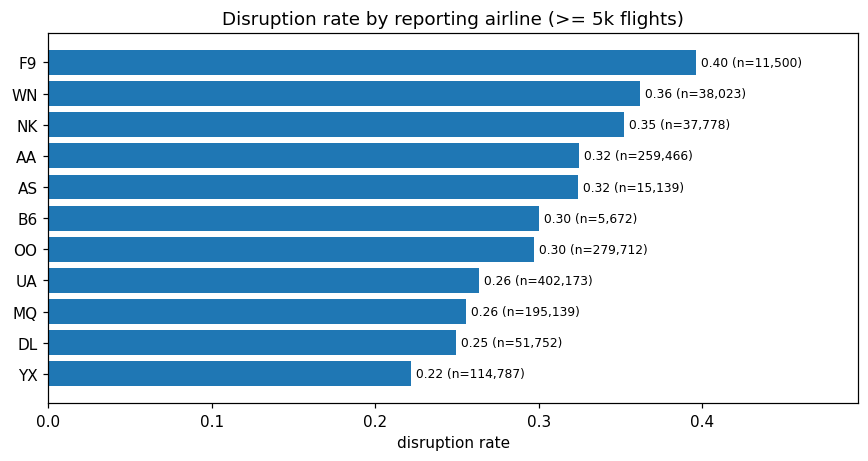

In [4]:
by_air = (flights.groupby("reporting_airline")["disrupted"]
                 .agg(["mean", "size"])
                 .query("size > 5000")
                 .sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(8, 0.3 * len(by_air) + 1))
ax.barh(by_air.index[::-1], by_air["mean"][::-1], color="C0")
ax.set_xlabel("disruption rate")
ax.set_title("Disruption rate by reporting airline (>= 5k flights)")
for i, (c, n) in enumerate(zip(by_air["mean"][::-1], by_air["size"][::-1])):
    ax.text(c + 0.003, i, f"{c:.2f} (n={n:,})", va="center", fontsize=8)
ax.set_xlim(0, by_air["mean"].max() * 1.25)
plt.tight_layout()
plt.show()


### Disruption rate by top-20 destination

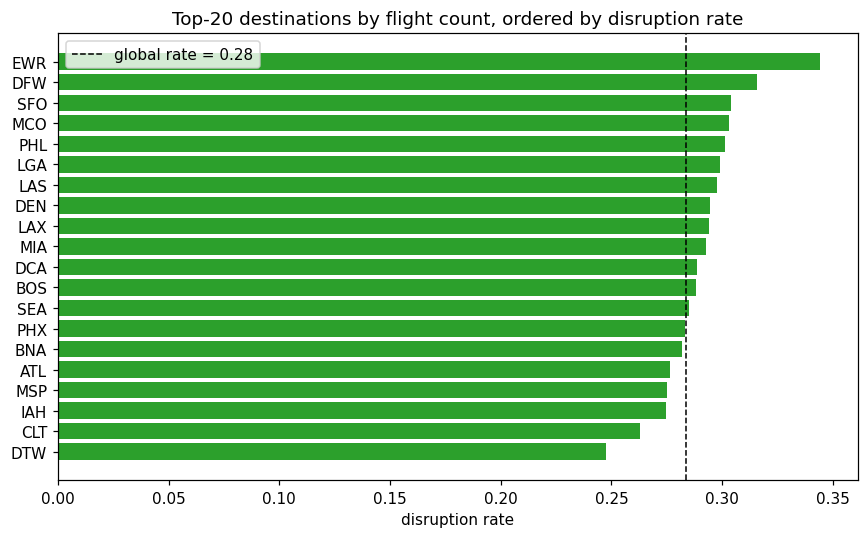

In [5]:
top = (flights.groupby("dest")["disrupted"]
              .agg(["mean", "size"])
              .sort_values("size", ascending=False)
              .head(20)
              .sort_values("mean", ascending=False))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index[::-1], top["mean"][::-1], color="C2")
ax.axvline(flights["disrupted"].mean(), color="black", ls="--",
           lw=1, label=f"global rate = {flights['disrupted'].mean():.2f}")
ax.set_xlabel("disruption rate")
ax.set_title("Top-20 destinations by flight count, ordered by disruption rate")
ax.legend()
plt.tight_layout()
plt.show()


### Weather and disruption

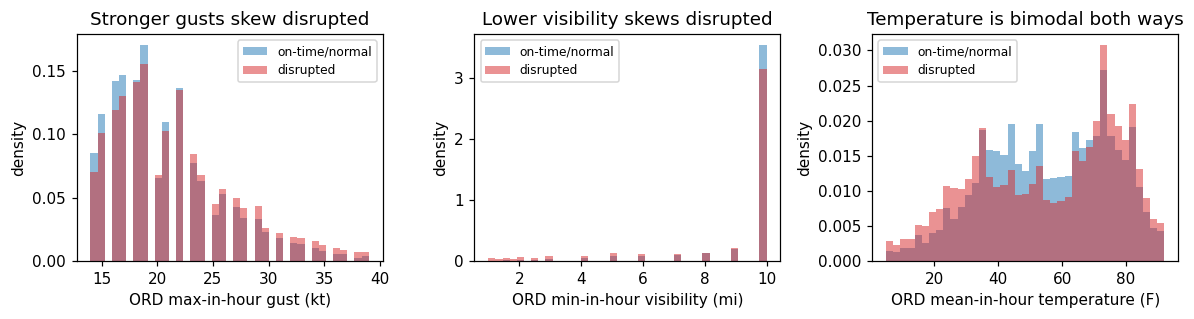

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, col, label in zip(axes,
        ["origin_wx_gust", "origin_wx_vsby", "origin_wx_tmpf"],
        ["ORD max-in-hour gust (kt)", "ORD min-in-hour visibility (mi)",
         "ORD mean-in-hour temperature (F)"]):
    d0 = flights.loc[flights["disrupted"] == 0, col].dropna()
    d1 = flights.loc[flights["disrupted"] == 1, col].dropna()
    bins = np.linspace(d0.quantile(0.005), d0.quantile(0.995), 40)
    ax.hist(d0, bins=bins, density=True, alpha=0.5, label="on-time/normal", color="C0")
    ax.hist(d1, bins=bins, density=True, alpha=0.5, label="disrupted", color="C3")
    ax.set_xlabel(label); ax.set_ylabel("density")
    ax.legend(fontsize=8)
axes[0].set_title("Stronger gusts skew disrupted")
axes[1].set_title("Lower visibility skews disrupted")
axes[2].set_title("Temperature is bimodal both ways")
plt.tight_layout(); plt.show()


## 3. Build train / val / test with noise

We reuse the exact same splitting + feature engineering + noise-injection
steps the production pipeline uses, so model comparisons are fair (same
inputs, only the model class changes).


In [7]:
rng = np.random.default_rng(SEED)
train, val, test = load_and_split(
    JOINED, TRAIN_START_DEFAULT, VAL_START_DEFAULT, TEST_START_DEFAULT)

# Per the pipeline: random per-flight lead for train + val.
train = add_sampled_leads(train, rng)
val   = add_sampled_leads(val,   rng)

noise = WeatherNoiseInjector.load(SIGMAS, seed=SEED).with_scale(1.0)
train = inject_noise(train, noise)
val   = inject_noise(val,   noise)

def _sklearn_friendly(X):
    """Two sklearn-1.8 pandas compatibility fixes that bite us at predict
    time: nullable Int dtypes carry pd.NA (sklearn imputer can't handle),
    and Categorical cols with unseen levels also carry pd.NA. Cast Int->
    float and convert categoricals to plain string with a sentinel.
    Lossless: HistGBT and LightGBM both accept the converted form."""
    X = X.copy()
    for c in X.select_dtypes(include=["Int64", "Int32", "Int16", "Int8"]).columns:
        X[c] = X[c].astype("float64")
    return X

X_train, cats = prepare_features(train)
X_val,   _    = prepare_features(val, cat_categories=cats)
X_train = _sklearn_friendly(X_train)
X_val   = _sklearn_friendly(X_val)
y_train = train["disrupted"].astype("int8").to_numpy()
y_val   = val["disrupted"].astype("int8").to_numpy()

print(f"train: {len(X_train):,} x {X_train.shape[1]}    val: {len(X_val):,}")
print("feature dtypes:")
print(X_train.dtypes.value_counts())


train: 1,279,763 x 52    val: 87,577
feature dtypes:
float64     49
category     1
category     1
category     1
Name: count, dtype: int64


Test set uses **per-occasion** structure: at each issue time
(every 6h in the test period) take all flights in the next 48 h, score
them using their *real* lead from that issue, and aggregate.

In [8]:
test_end = pd.to_datetime(test["scheduled_dep_utc_hour"]).max().ceil("D")
occ = build_test_occasions(test, TEST_START_DEFAULT, test_end)
occ = inject_noise(occ, noise)
X_test, _ = prepare_features(occ, cat_categories=cats)
X_test = _sklearn_friendly(X_test)
y_test = occ["disrupted"].astype("int8").to_numpy()
print(f"test (occasion, flight) rows: {len(X_test):,}")
print(f"test occasions:               {occ['occasion_id'].nunique():,}")


test (occasion, flight) rows: 401,543
test occasions:               237


## 4. Fit three models

### 4a. Logistic regression baseline

In [9]:
# LR needs imputation + scaling for numerics and one-hot for categoricals.
# We stringify Category cols with a __missing__ sentinel here so the OHE
# step never sees pd.NA (sklearn's imputer in 1.8 trips on pd.NA in object
# arrays). Subsample train for speed -- 200k rows is plenty for a baseline.

def for_lr(X):
    X = X.copy()
    for c in X.select_dtypes(include=["category"]).columns:
        X[c] = X[c].astype("string").fillna("__missing__")
    return X

sub = X_train.sample(n=min(200_000, len(X_train)), random_state=SEED)
sub_y = y_train[sub.index]
sub_lr   = for_lr(sub)
X_val_lr = for_lr(X_val)

num_cols = sub_lr.select_dtypes(include=["float64", "float32",
                                          "int8", "int64"]).columns.tolist()
cat_cols = sub_lr.select_dtypes(include=["string", "object"]).columns.tolist()
print(f"LR features: {len(num_cols)} numeric  {len(cat_cols)} categorical")

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]),
     num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=0.001),
     cat_cols),
])
lr = Pipeline([("pre", pre),
               ("clf", LogisticRegression(max_iter=200, solver="lbfgs"))])
print(f"fitting LR on {len(sub):,} rows...")
%time lr.fit(sub_lr, sub_y)

p_val_lr = lr.predict_proba(X_val_lr)[:, 1]
print(f"LR val AUC={roc_auc_score(y_val, p_val_lr):.4f}  "
      f"AUC-PR={average_precision_score(y_val, p_val_lr):.4f}  "
      f"Brier={brier_score_loss(y_val, p_val_lr):.4f}")


LR features: 49 numeric  3 categorical
fitting LR on 200,000 rows...


CPU times: user 2.01 s, sys: 40.8 ms, total: 2.06 s
Wall time: 2.07 s
LR val AUC=0.6538  AUC-PR=0.5134  Brier=0.2338


### 4b. LightGBM

In [10]:
# LightGBM handles NaN + native categorical via pandas Categorical dtype.
lgbm = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=200, subsample=0.9, colsample_bytree=0.9,
    objective="binary", random_state=SEED, n_jobs=-1, verbose=-1,
)
print(f"fitting LightGBM on {len(X_train):,} rows...")
%time lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)], \
               callbacks=[lgb.early_stopping(20, verbose=False)])

p_val_lgbm = lgbm.predict_proba(X_val)[:, 1]
print(f"LightGBM val AUC={roc_auc_score(y_val, p_val_lgbm):.4f}  "
      f"AUC-PR={average_precision_score(y_val, p_val_lgbm):.4f}  "
      f"Brier={brier_score_loss(y_val, p_val_lgbm):.4f}")


fitting LightGBM on 1,279,763 rows...


CPU times: user 26.5 s, sys: 3.45 s, total: 30 s
Wall time: 5.99 s
LightGBM val AUC=0.7121  AUC-PR=0.6073  Brier=0.2183


### 4c. HistGradientBoosting (the production model)

In [11]:
# Reuse the model trained by src.training_pipeline if present, otherwise
# train a fresh one with the same hyperparams.
ckpt = ARTIFACTS / "model.joblib"
if ckpt.exists():
    payload = joblib.load(ckpt)
    hgb = payload["model"]
    print(f"loaded pre-trained HistGBT from {ckpt}")
else:
    hgb = HistGradientBoostingClassifier(
        loss="log_loss", learning_rate=0.05, max_iter=500,
        max_leaf_nodes=63, min_samples_leaf=200,
        categorical_features="from_dtype",
        early_stopping=True, n_iter_no_change=20, random_state=SEED,
    )
    print(f"fitting HistGBT on {len(X_train):,} rows...")
    %time hgb.fit(X_train, y_train)

p_val_hgb = hgb.predict_proba(X_val)[:, 1]
print(f"HistGBT val AUC={roc_auc_score(y_val, p_val_hgb):.4f}  "
      f"AUC-PR={average_precision_score(y_val, p_val_hgb):.4f}  "
      f"Brier={brier_score_loss(y_val, p_val_hgb):.4f}")


loaded pre-trained HistGBT from /Users/evanbarnett/Desktop/Northwestern/Classes/de300/plane_forecasting/artifacts/disruption_model/model.joblib


HistGBT val AUC=0.7102  AUC-PR=0.6028  Brier=0.2187


## 5. Test-set metrics (per flight, then per occasion)

In [12]:
X_test_lr = for_lr(X_test)
p_test = {
    "Logistic":   lr.predict_proba(X_test_lr)[:, 1],
    "LightGBM":   lgbm.predict_proba(X_test)[:, 1],
    "HistGBT":    hgb.predict_proba(X_test)[:, 1],
}

rows = []
for name, p in p_test.items():
    rows.append({
        "model": name,
        "AUC-ROC": roc_auc_score(y_test, p),
        "AUC-PR":  average_precision_score(y_test, p),
        "Brier":   brier_score_loss(y_test, p),
        "Brier vs base": brier_score_loss(y_test, np.full_like(p, y_test.mean())),
    })
pd.DataFrame(rows).set_index("model")


,AUC-ROC,AUC-PR,Brier,Brier vs base
model,,,,
Logistic,0.6657,0.5292,0.2201,0.2303
LightGBM,0.7196,0.6179,0.2001,0.2303
HistGBT,0.7157,0.6117,0.2018,0.2303


### Per-occasion (the actual deliverable: 48 h aggregate disruption rate)

In [13]:
def per_occ(p):
    t = per_occasion_table(occ, p)
    return {
        "MAE":     t["abs_error"].mean(),
        "RMSE":    np.sqrt((t["signed_error"] ** 2).mean()),
        "bias":    t["signed_error"].mean(),
        "Pearson": t[["actual_rate", "predicted_rate"]].corr().iloc[0, 1],
    }

rows = [{"model": name, **per_occ(p)} for name, p in p_test.items()]
occ_metrics = pd.DataFrame(rows).set_index("model")
occ_metrics


,MAE,RMSE,bias,Pearson
model,,,,
Logistic,0.1177,0.1615,-0.0893,0.6571
LightGBM,0.0839,0.1037,-0.0629,0.8869
HistGBT,0.0878,0.1074,-0.0692,0.8802


## 6. Calibration

A calibration plot bins predictions by predicted probability and compares
the *mean predicted probability* in each bin to the *observed frequency*
of the positive class. A perfectly calibrated model lies on the diagonal.
Off-diagonal up-and-to-the-left = under-confident; down-and-to-the-right =
over-confident. The *bias* row in the table above is the global version
of this signal.


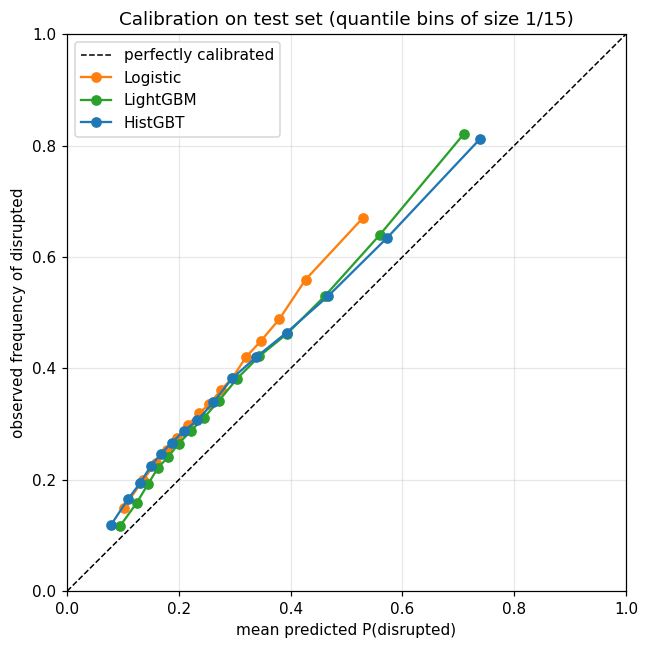

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
colors = {"Logistic": "C1", "LightGBM": "C2", "HistGBT": "C0"}

for name, p in p_test.items():
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=15,
                                             strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", color=colors[name], label=name)

ax.set_xlabel("mean predicted P(disrupted)")
ax.set_ylabel("observed frequency of disrupted")
ax.set_title("Calibration on test set (quantile bins of size 1/15)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


All three models track the diagonal up to roughly the test base rate (~0.36), then **under-predict** in the high-risk regime — exactly the regime-shift symptom flagged in the README. A post-hoc isotonic calibrator fit on validation would pull these curves back to the diagonal without retraining the models.

## 7. Per-occasion predicted vs actual rate

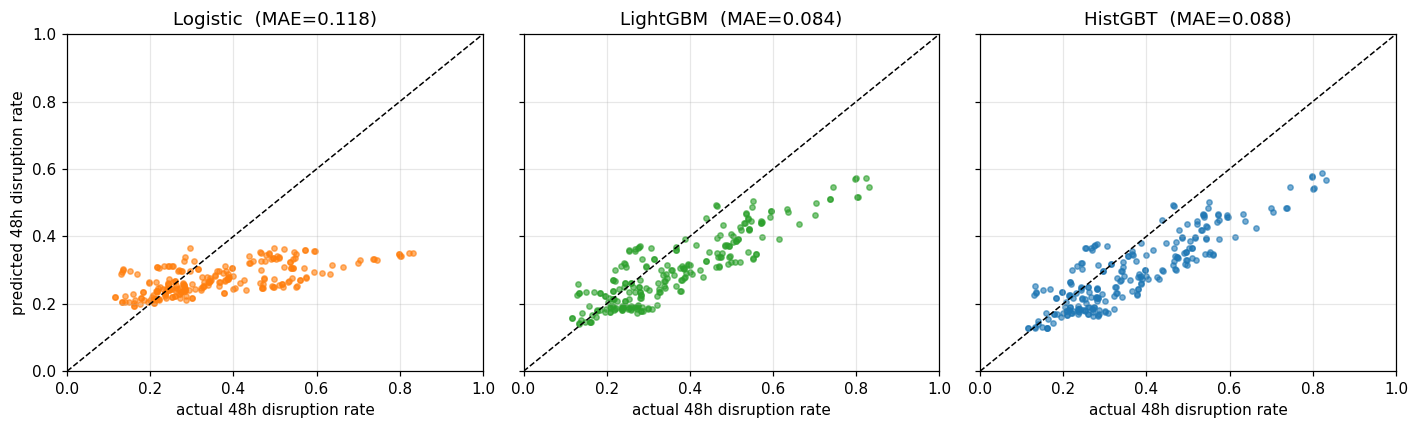

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, (name, p) in zip(axes, p_test.items()):
    t = per_occasion_table(occ, p)
    ax.scatter(t["actual_rate"], t["predicted_rate"], s=12, alpha=0.6,
               color=colors[name])
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(f"{name}  (MAE={t['abs_error'].mean():.3f})")
    ax.set_xlabel("actual 48h disruption rate")
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes[0].set_ylabel("predicted 48h disruption rate")
plt.tight_layout(); plt.show()


## 8. LightGBM feature importance

Three complementary views:

- **Gain**: total reduction in loss attributable to splits on this
  feature. "What did the trained model rely on most?"  Intrinsic to
  the model, free to compute.
- **Split count**: how many times the feature was used as a split.
  Sanity check — when split-count is high but gain is low it usually
  signals a noisy / weakly-informative feature that the model kept
  trying and getting marginal wins from.
- **Permutation importance**: drop in test-set score when the feature
  is randomly shuffled. "What would test performance lose if this
  feature were missing?" Extrinsic and model-agnostic; the gold
  standard but expensive — computed on a 30k-row test subsample here.


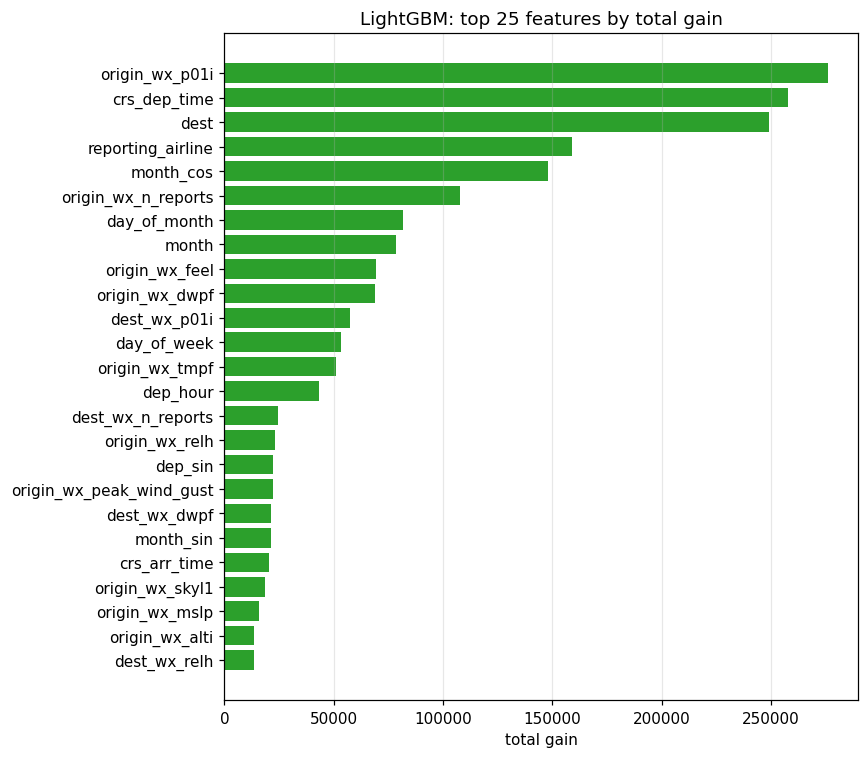

top 10 by gain account for 75.2% of total gain


In [16]:
imp = pd.DataFrame({
    "feature": lgbm.feature_name_,
    "gain":    lgbm.booster_.feature_importance(importance_type="gain"),
    "split":   lgbm.booster_.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False).reset_index(drop=True)

top = imp.head(25)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top["feature"][::-1], top["gain"][::-1], color="C2")
ax.set_xlabel("total gain")
ax.set_title("LightGBM: top 25 features by total gain")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"top 10 by gain account for "
      f"{100 * imp.head(10)['gain'].sum() / imp['gain'].sum():.1f}% "
      f"of total gain")


### Split-count vs gain

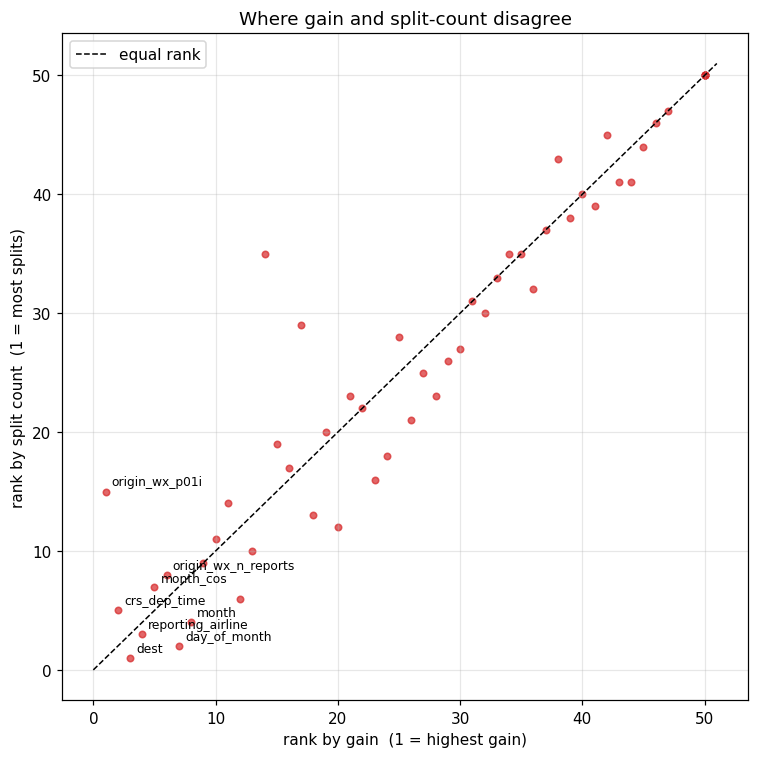

In [17]:
# Re-rank by split count and overlay against gain rank.
imp["gain_rank"] = imp["gain"].rank(ascending=False).astype(int)
imp["split_rank"] = imp["split"].rank(ascending=False).astype(int)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(imp["gain_rank"], imp["split_rank"], s=18, alpha=0.7, color="C3")
lim = max(imp["gain_rank"].max(), imp["split_rank"].max()) + 1
ax.plot([0, lim], [0, lim], "k--", lw=1, label="equal rank")
# Label the top 8 by gain
for _, r in imp.head(8).iterrows():
    ax.annotate(r["feature"], (r["gain_rank"], r["split_rank"]),
                xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("rank by gain  (1 = highest gain)")
ax.set_ylabel("rank by split count  (1 = most splits)")
ax.set_title("Where gain and split-count disagree")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Permutation importance on the test set

Shuffles each feature in turn, scores the model with
``neg_brier_score`` (higher is better), and reports the drop. Bars are
mean over 3 repeats; the error bar shows ± 1 std across repeats.
A feature whose interval brushes zero is essentially noise to the model
at test time.


computing permutation importance on 30,000 test rows x 52 features (3 repeats)...


CPU times: user 1.73 s, sys: 170 ms, total: 1.9 s
Wall time: 9.51 s


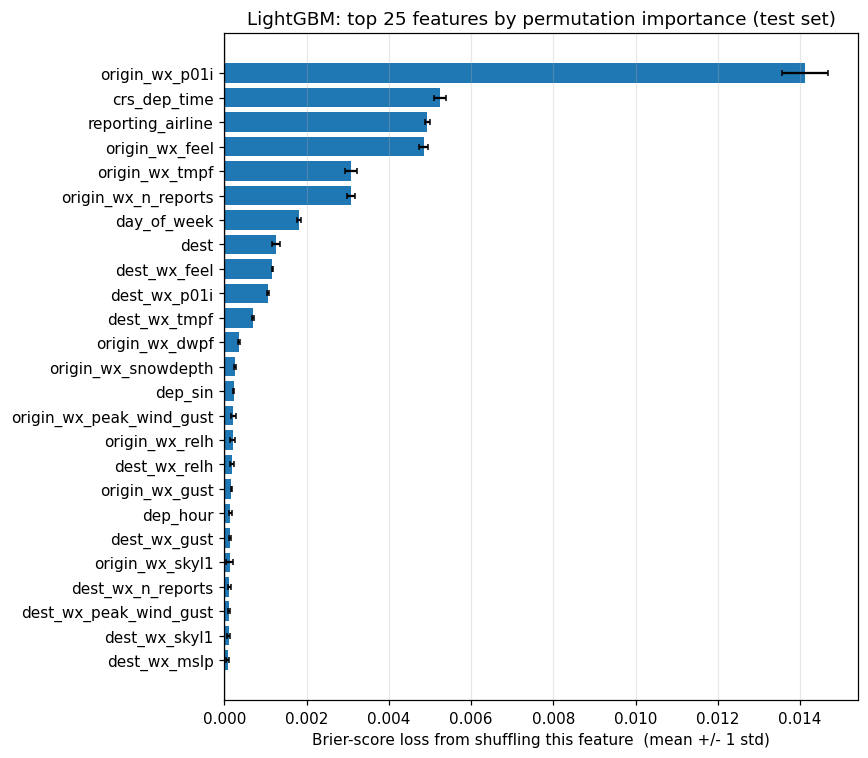

in top-15 of both gain and permutation: ['crs_dep_time', 'day_of_week', 'dest', 'dest_wx_p01i', 'origin_wx_dwpf', 'origin_wx_feel', 'origin_wx_n_reports', 'origin_wx_p01i', 'origin_wx_tmpf', 'reporting_airline']
top-15 by gain only: ['day_of_month', 'dep_hour', 'dest_wx_n_reports', 'month', 'month_cos']
top-15 by permutation only: ['dep_sin', 'dest_wx_feel', 'dest_wx_tmpf', 'origin_wx_peak_wind_gust', 'origin_wx_snowdepth']


In [18]:
from sklearn.inspection import permutation_importance

rng_pi = np.random.default_rng(SEED)
sample_idx = rng_pi.choice(len(X_test), size=min(30_000, len(X_test)),
                            replace=False)
X_pi = X_test.iloc[sample_idx]
y_pi = y_test[sample_idx]

print(f"computing permutation importance on {len(X_pi):,} test rows "
      f"x {X_pi.shape[1]} features (3 repeats)...")
%time pi = permutation_importance(lgbm, X_pi, y_pi, \
        scoring="neg_brier_score", n_repeats=3, random_state=SEED, n_jobs=-1)

pi_df = (pd.DataFrame({
        "feature": X_pi.columns,
        "mean": pi.importances_mean,
        "std":  pi.importances_std,
    })
    .sort_values("mean", ascending=False)
    .reset_index(drop=True)
)

top_pi = pi_df.head(25)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_pi["feature"][::-1], top_pi["mean"][::-1],
        xerr=top_pi["std"][::-1], color="C0", ecolor="black", capsize=2)
ax.set_xlabel("Brier-score loss from shuffling this feature  (mean +/- 1 std)")
ax.set_title("LightGBM: top 25 features by permutation importance (test set)")
ax.axvline(0, color="black", lw=0.8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

# Quick comparison: which features appear in top-15 of both rankings?
top_gain = set(imp.head(15)["feature"])
top_perm = set(pi_df.head(15)["feature"])
print(f"in top-15 of both gain and permutation: "
      f"{sorted(top_gain & top_perm)}")
print(f"top-15 by gain only: {sorted(top_gain - top_perm)}")
print(f"top-15 by permutation only: {sorted(top_perm - top_gain)}")


### Reading the importance plots

- **Both rankings agree on the same core set** of ~10 features:
  schedule (`crs_dep_time`, `day_of_week`), route (`dest`,
  `reporting_airline`), and weather at both endpoints —
  `*_wx_tmpf`, `*_wx_dwpf`, `*_wx_feel`, `*_wx_p01i`, plus
  `*_wx_n_reports`. That overlap is the reliable signal; build features
  on top of these first.
- **`n_reports` ranks surprisingly high.** It's the count of
  sub-hourly METARs that fed each hourly aggregate row -- intended as
  a diagnostic, not a feature. Low `n_reports` correlates with
  degraded ASOS reporting (station outages, severe weather knocking
  the sensor off-line), so it's acting as a *proxy* for "the airport
  is operationally compromised". Useful, but worth knowing what it
  actually is before drawing causal conclusions.
- **Lead time is conspicuously absent** from the top-15 of either
  ranking. The trees don't appear to be conditioning much on
  `lead_origin_h` / `lead_dest_h`, even though noise scales with
  lead. Two possible explanations: (i) the weather features
  themselves already carry the lead-conditional uncertainty via the
  injected noise, so an explicit lead split is redundant; or (ii)
  the lead-dependence really is weak for this prediction task at
  this horizon and the noise model is too uniform. Worth a closer
  look in a follow-up.
- **Where gain and permutation disagree:** gain over-credits
  correlated calendar features (`month`, `month_cos`, `day_of_month`,
  `dep_hour`) because the trees split on whichever variant is
  convenient at each node — permutation, which measures *unique*
  information, correctly downweights them. Conversely permutation
  promotes features the trees use in only a few high-leverage splits
  (`origin_wx_peak_wind_gust`, `origin_wx_snowdepth`,
  `dest_wx_tmpf`, `dest_wx_feel`). For "what should I keep in the
  feature set" use permutation; for "what is the trained model
  doing" use gain.